<a href="https://colab.research.google.com/github/abhishektuteja01/options-pricer/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option Pricing with Black–Scholes and Machine Learning
------------------------------------------------------

### This project explores whether machine learning models can better approximate real-world option prices compared to the classical Black–Scholes formula.

**Workflow Overview:**
1. Download live option chain data using yfinance.
2. Clean and preprocess the dataset using pandas.
3. Compute financial features such as:
   - Greeks (Delta, Gamma, Theta, Vega, Rho)
   - Moneyness and log-moneyness
   - Historical volatility
   - Black–Scholes theoretical price
4. Train multiple predictive models on log(mid price):
   - Linear Regression (baseline linear model)
   - Random Forest Regressor
   - XGBoost Regressor
5. Compare each model’s performance against market mid-prices using:
   MAE, RMSE, R², and SMAPE.
6. Visualize predicted vs actual prices and analyze results.

This notebook demonstrates how combining classical financial theory with
modern machine learning can reveal deeper structure in option pricing
and significantly improve predictive accuracy. **bold text**


# 1. Setup and Imports

In [ ]:
# Install dependencies (needed in environments like Google Colab)
!pip install yfinance xgboost --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timezone
from scipy.stats import norm  # for Black–Scholes

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

In [ ]:
# Configuration
TICKERS = ["AAPL", "MSFT", "TSLA", "SPY"]     # Underlyings to analyze
N_EXPIRIES = 5                                # Number of nearest expiries to fetch
HV_LOOKBACK = 60                               # Days for historical volatility calculation
RISK_FREE_RATE = 0.04                          # Annual risk-free interest rate
TODAY = datetime.now(timezone.utc).date()      # Current date (UTC)

# Summary
print("Tickers:", TICKERS)
print("Expiries per ticker:", N_EXPIRIES)
print("Historical vol lookback:", HV_LOOKBACK, "days")
print("Risk-free rate:", RISK_FREE_RATE)
print("Today:", TODAY)

Tickers: ['AAPL', 'MSFT', 'TSLA', 'SPY']
Expiries per ticker: 5
Historical vol lookback: 60 days
Risk-free rate: 0.04
Today: 2025-12-09


# 2. Data Acquisition & Preprocessing (Underlyings)

## 📈 Underlying Prices & Historical Volatility

Before downloading option chains, we collect 1 year of historical price data for each
underlying ticker. From this, we compute:

- **Spot price** (latest closing price)
- **Daily log returns**
- **Recent historical volatility** (annualized over the last HV_LOOKBACK days)

These values are useful as reference inputs and help contextualize option pricing behavior.

In [ ]:
# Compute spot price and historical volatility for each underlying

spot_map = {}
sigma_map = {}

for ticker in TICKERS:
    t = yf.Ticker(ticker)

    # Fetch 1 year of historical data
    hist = t.history(period="1y")

    # Daily log returns
    hist["log_return"] = np.log(hist["Close"] / hist["Close"].shift(1))
    recent_returns = hist["log_return"].dropna().tail(HV_LOOKBACK)

    # Historical volatility (annualized)
    daily_vol = recent_returns.std()
    sigma = daily_vol * np.sqrt(252)

    # Latest spot price
    spot = hist["Close"].iloc[-1]

    spot_map[ticker] = spot
    sigma_map[ticker] = sigma

    print(f"{ticker}: Spot={spot:.2f}, HistVol={sigma:.4f}, n={len(recent_returns)}")

spot_map, sigma_map

AAPL: Spot=277.89, HistVol=0.2062, n=60
MSFT: Spot=491.02, HistVol=0.1903, n=60
TSLA: Spot=439.58, HistVol=0.4879, n=60
SPY: Spot=683.63, HistVol=0.1240, n=60


({'AAPL': np.float64(277.8900146484375),
  'MSFT': np.float64(491.0199890136719),
  'TSLA': np.float64(439.5799865722656),
  'SPY': np.float64(683.6300048828125)},
 {'AAPL': np.float64(0.20619752089003887),
  'MSFT': np.float64(0.19030464347317633),
  'TSLA': np.float64(0.4879177343865593),
  'SPY': np.float64(0.12402734669168686)})

# 3. Option Chain Download & Raw Dataset

Next, we download option chain data for each underlying using `yfinance`. For each
ticker, we:

- Fetch the list of available expirations
- For the nearest `N_EXPIRIES` expiries:
  - Download both calls and puts
  - Attach metadata such as:
    - Underlying ticker
    - Expiration date
    - Time to maturity (in years)
    - Risk-free rate
    - Current spot price
- Combine all rows into a single raw `DataFrame` for further cleaning.

This step gives us a unified options dataset across tickers, expiries, and option types.

In [ ]:
# Download option chains and build a combined raw dataset

all_rows = []

for ticker in TICKERS:
    t = yf.Ticker(ticker)
    expiries = t.options or []
    print(f"\nTicker: {ticker}, expiries available: {len(expiries)}")

    # Latest spot price S (1-day history)
    hist = t.history(period="1d")
    if hist.empty:
        print(f"  No history for {ticker}, skipping.")
        continue
    S = float(hist["Close"].iloc[-1])

    # Process the nearest N_EXPIRIES expirations
    for exp in expiries[:N_EXPIRIES]:
        # Time to maturity T (in years)
        expiry_dt = datetime.strptime(exp, "%Y-%m-%d").replace(tzinfo=timezone.utc)
        now_dt = datetime.now(timezone.utc)
        days_to_expiry = (expiry_dt - now_dt).total_seconds() / (24 * 3600)
        T = max(days_to_expiry / 365.0, 1e-6)  # avoid zero or negative T

        try:
            chain = t.option_chain(exp)
        except Exception as e:
            print(f"  Failed to load chain for {ticker} {exp}: {e}")
            continue

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # Common metadata
        for df_ in (calls, puts):
            df_["underlying"] = ticker
            df_["expiration"] = exp
            df_["S"] = S
            df_["T"] = T
            df_["r"] = RISK_FREE_RATE

        calls["type"] = "call"
        puts["type"] = "put"

        all_rows.append(calls)
        all_rows.append(puts)

# Combine everything into a single DataFrame
df = pd.concat(all_rows, ignore_index=True)
print("\nCombined raw dataset shape:", df.shape)
display(df.head())


Ticker: AAPL, expiries available: 21

Ticker: MSFT, expiries available: 21

Ticker: TSLA, expiries available: 21

Ticker: SPY, expiries available: 32

Combined raw dataset shape: (3490, 20)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,underlying,expiration,S,T,r,type
0,AAPL251212C00120000,2025-11-14 19:27:23+00:00,120.0,154.48,156.05,159.15,0.000000,0.000000,1.0,1.0,4.501957,True,REGULAR,USD,AAPL,2025-12-12,277.890015,0.008067,0.04,call
1,AAPL251212C00150000,2025-12-01 20:24:47+00:00,150.0,127.50,126.10,129.15,-4.190002,-3.181716,1.0,2.0,3.424806,True,REGULAR,USD,AAPL,2025-12-12,277.890015,0.008067,0.04,call
2,AAPL251212C00155000,2025-11-28 17:50:00+00:00,155.0,123.05,121.05,124.20,0.000000,0.000000,1.0,1.0,3.291017,True,REGULAR,USD,AAPL,2025-12-12,277.890015,0.008067,0.04,call
3,AAPL251212C00160000,2025-11-28 17:55:00+00:00,160.0,119.00,116.10,119.15,0.000000,0.000000,1.0,3.0,3.111330,True,REGULAR,USD,AAPL,2025-12-12,277.890015,0.008067,0.04,call
4,AAPL251212C00170000,2025-12-04 14:43:58+00:00,170.0,113.23,106.10,109.20,0.000000,0.000000,2.0,3.0,2.838870,True,REGULAR,USD,AAPL,2025-12-12,277.890015,0.008067,0.04,call


# 4. Data Cleaning

We now clean and standardize the raw option chain dataset. This includes:

- Ensuring a consistent implied volatility column  
- Computing the mid-price using bid/ask (and falling back to last traded price)  
- Converting key fields to numeric  
- Removing rows with missing or invalid pricing inputs  
- Ensuring positive strike, time-to-expiry, IV, and mid price  

This step prepares the dataset for feature engineering and modeling.

In [ ]:
# -----------------------------------------
# Data Cleaning: mid price, IV, numerics
# -----------------------------------------

# Ensure consistent implied volatility column
df["implied_volatility"] = (
    df["impliedVolatility"] if "impliedVolatility" in df.columns else np.nan
)

# Compute mid price from bid/ask; fallback to last traded price
df["mid"] = (df["bid"] + df["ask"]) / 2
df["mid"] = df["mid"].fillna(df["lastPrice"])
df.loc[df["mid"] <= 0, "mid"] = df["lastPrice"]  # avoid zeros

# Convert critical columns to numeric
critical_cols = ["strike", "mid", "implied_volatility", "S", "T"]
for col in critical_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with invalid or missing core pricing fields
df = df.dropna(subset=critical_cols)
df = df[
    (df["mid"] > 0) &
    (df["implied_volatility"] > 0) &
    (df["strike"] > 0) &
    (df["S"] > 0) &
    (df["T"] > 0)
]

print("After basic cleaning, shape:", df.shape)
display(df[["underlying", "expiration", "type", "strike", "mid", "implied_volatility"]].head())

After basic cleaning, shape: (3490, 22)


,underlying,expiration,type,strike,mid,implied_volatility
0,AAPL,2025-12-12,call,120.0,157.600,4.501957
1,AAPL,2025-12-12,call,150.0,127.625,3.424806
2,AAPL,2025-12-12,call,155.0,122.625,3.291017
3,AAPL,2025-12-12,call,160.0,117.625,3.111330
4,AAPL,2025-12-12,call,170.0,107.650,2.838870


# 5. Feature Engineering – Greeks (Δ, Γ, Θ, Vega, ρ)

Using the cleaned option dataset, we now compute the Black–Scholes Greeks for each
option contract:

- Delta (Δ): sensitivity to underlying price
- Gamma (Γ): sensitivity of Delta to underlying price
- Theta (Θ): time decay
- Vega: sensitivity to volatility
- Rho (ρ): sensitivity to interest rates

We assume no dividends and use the `implied_volatility` column as σ in the
Black–Scholes formulas.

In [ ]:
# -----------------------------------------
# Feature Engineering: Black–Scholes Greeks
# -----------------------------------------

def bs_d1_d2(S, K, T, r, sigma):
    """
    Compute the Black–Scholes d1 and d2 terms.

    Parameters
    ----------
    S : float
        Spot price of the underlying.
    K : float
        Strike price of the option.
    T : float
        Time to maturity in years.
    r : float
        Risk-free interest rate (annualized).
    sigma : float
        Volatility (annualized).

    Returns
    -------
    d1, d2 : float
        Black–Scholes d1 and d2 values. (nan, nan) if inputs are invalid.
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan, np.nan

    sqrt_T = np.sqrt(T)
    numer = np.log(S / K) + (r + 0.5 * sigma**2) * T
    denom = sigma * sqrt_T

    d1 = numer / denom
    d2 = d1 - sigma * sqrt_T
    return d1, d2


def compute_greeks_row(row):
    """
    Compute Black–Scholes Greeks (Delta, Gamma, Theta, Vega, Rho)
    for a single option row in the DataFrame.

    Uses `implied_volatility` as sigma and assumes no dividends.
    """
    S_val = float(row["S"])
    K_val = float(row["strike"])
    T_val = float(row["T"])
    r_val = float(row["r"])
    sigma_val = float(row["implied_volatility"])
    opt_type = row["type"]

    d1, d2 = bs_d1_d2(S_val, K_val, T_val, r_val, sigma_val)
    if np.isnan(d1) or np.isnan(d2):
        return pd.Series([np.nan] * 5, index=["delta", "gamma", "theta", "vega", "rho"])

    pdf_d1 = norm.pdf(d1)

    # Delta
    if opt_type == "call":
        delta = norm.cdf(d1)
    else:  # put
        delta = norm.cdf(d1) - 1

    # Gamma
    gamma = pdf_d1 / (S_val * sigma_val * np.sqrt(T_val))

    # Vega
    vega = S_val * pdf_d1 * np.sqrt(T_val)

    # Theta (no dividends)
    if opt_type == "call":
        theta = (
            - (S_val * pdf_d1 * sigma_val) / (2 * np.sqrt(T_val))
            - r_val * K_val * np.exp(-r_val * T_val) * norm.cdf(d2)
        )
    else:  # put
        theta = (
            - (S_val * pdf_d1 * sigma_val) / (2 * np.sqrt(T_val))
            + r_val * K_val * np.exp(-r_val * T_val) * norm.cdf(-d2)
        )

    # Rho
    if opt_type == "call":
        rho = K_val * T_val * np.exp(-r_val * T_val) * norm.cdf(d2)
    else:
        rho = -K_val * T_val * np.exp(-r_val * T_val) * norm.cdf(-d2)

    return pd.Series(
        [delta, gamma, theta, vega, rho],
        index=["delta", "gamma", "theta", "vega", "rho"],
    )


# Apply to all rows
greeks = df.apply(compute_greeks_row, axis=1)
df = pd.concat([df, greeks], axis=1)

# Drop rows where Greeks failed
df = df.dropna(subset=["delta", "gamma", "theta", "vega", "rho"])

print("After adding Greeks, shape:", df.shape)
display(
    df[
        [
            "underlying",
            "expiration",
            "type",
            "strike",
            "mid",
            "implied_volatility",
            "delta",
            "gamma",
            "theta",
            "vega",
            "rho",
        ]
    ].head()
)

After adding Greeks, shape: (3490, 27)


,underlying,expiration,type,strike,mid,implied_volatility,delta,gamma,theta,vega,rho
0,AAPL,2025-12-12,call,120.0,157.600,4.501957,0.988688,0.000264,-211.308386,0.740599,0.938328
1,AAPL,2025-12-12,call,150.0,127.625,3.424806,0.984589,0.000453,-211.167561,0.967433,1.170901
2,AAPL,2025-12-12,call,155.0,122.625,3.291017,0.983163,0.000509,-218.874913,1.043649,1.207785
3,AAPL,2025-12-12,call,160.0,117.625,3.111330,0.982844,0.000547,-210.698172,1.060499,1.247570
4,AAPL,2025-12-12,call,170.0,107.650,2.838870,0.980114,0.000680,-218.168401,1.202643,1.321797


In [ ]:
# -----------------------------------------
# Feature Engineering: Black–Scholes Price
# -----------------------------------------

def bs_price_row(row):
    """
    Compute the Black–Scholes theoretical option price for a single row,
    using implied_volatility as sigma and assuming no dividends.
    """
    S_val = float(row["S"])
    K_val = float(row["strike"])
    T_val = float(row["T"])
    r_val = float(row["r"])
    sigma_val = float(row["implied_volatility"])
    opt_type = row["type"]

    d1, d2 = bs_d1_d2(S_val, K_val, T_val, r_val, sigma_val)
    if np.isnan(d1) or np.isnan(d2):
        return np.nan

    disc_factor = np.exp(-r_val * T_val)

    if opt_type == "call":
        price = S_val * norm.cdf(d1) - K_val * disc_factor * norm.cdf(d2)
    else:  # put
        price = K_val * disc_factor * norm.cdf(-d2) - S_val * norm.cdf(-d1)

    return price


# Apply to full DataFrame
df["bs_price"] = df.apply(bs_price_row, axis=1)

print("Added Black–Scholes theoretical prices.")
display(df[["underlying", "expiration", "type", "strike", "mid", "bs_price"]].head())

Added Black–Scholes theoretical prices.


,underlying,expiration,type,strike,mid,bs_price
0,AAPL,2025-12-12,call,120.0,157.600,158.428513
1,AAPL,2025-12-12,call,150.0,127.625,128.458809
2,AAPL,2025-12-12,call,155.0,122.625,123.490313
3,AAPL,2025-12-12,call,160.0,117.625,118.469961
4,AAPL,2025-12-12,call,170.0,107.650,108.509736


In [ ]:
# ---------------------------------------------------------
# Feature Engineering: moneyness, encoding, numeric cleanup
# ---------------------------------------------------------

# Moneyness measures relative strike position
df["moneyness"] = df["S"] / df["strike"]
df["log_moneyness"] = np.log(df["moneyness"])

# Encode option type numerically
df["type_flag"] = df["type"].map({"call": 1, "put": 0})

# Columns required for modeling
numeric_cols = [
    "strike",
    "mid",
    "implied_volatility",
    "delta",
    "gamma",
    "theta",
    "vega",
    "rho",
    "moneyness",
    "log_moneyness",
    "T",
    "type_flag",
    "bs_price",
]

# Ensure all numeric columns convert properly
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows missing any modeling feature
df_clean = df.dropna(subset=numeric_cols)

print("Final cleaned dataset shape:", df_clean.shape)
display(df_clean[[
    "underlying", "expiration", "type",
    "strike", "mid", "implied_volatility", "moneyness", "T"
]].head())

Final cleaned dataset shape: (3490, 31)


,underlying,expiration,type,strike,mid,implied_volatility,moneyness,T
0,AAPL,2025-12-12,call,120.0,157.600,4.501957,2.315750,0.008067
1,AAPL,2025-12-12,call,150.0,127.625,3.424806,1.852600,0.008067
2,AAPL,2025-12-12,call,155.0,122.625,3.291017,1.792839,0.008067
3,AAPL,2025-12-12,call,160.0,117.625,3.111330,1.736813,0.008067
4,AAPL,2025-12-12,call,170.0,107.650,2.838870,1.634647,0.008067


## 6. PCA – Dimensionality Reduction

Before training models, we apply **Principal Component Analysis (PCA)** to a
standardized set of option features (strike, implied volatility, Greeks,
moneyness, time-to-expiry, and the type flag). This helps us:

- Understand which **combinations of features** explain most of the variance
  in the options dataset.
- Diagnose **redundancy** and **multicollinearity** between related inputs
  (for example, between Greeks and moneyness).
- Visualize the **structure of the option space** (e.g., calls vs puts,
  differences between underlyings, clustering by moneyness or maturity).

PCA is used here as an exploratory tool, not as the primary input to the
final pricing models, but it provides useful insight into how the engineered
features interact.

In [ ]:
# ---------------------------------------------------------
# PCA: Exploring variance structure in option features
# ---------------------------------------------------------

# Feature matrix used for PCA
features = [
    "strike",
    "implied_volatility",
    "delta",
    "gamma",
    "theta",
    "vega",
    "rho",
    "moneyness",
    "log_moneyness",
    "T",
    "type_flag",
]

# Extract the feature matrix
X = df_clean[features].values

# Standardize features before PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

# Run PCA (retain 5 components)
n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled_pca)

# Build PCA results DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
pca_df["type"] = df_clean["type"].values
pca_df["underlying"] = df_clean["underlying"].values

# Print variance explained
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))

display(pca_df.head())

# PCA loadings (how each original feature contributes)
components_df = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(n_components)],
)

print("\nFeature loadings:")
display(components_df)

Explained variance ratio per component:
[0.28679465 0.19467174 0.14507904 0.12612478 0.08572453]

Cumulative explained variance:
[0.28679465 0.48146639 0.62654543 0.75267022 0.83839475]


,PC1,PC2,PC3,PC4,PC5,type,underlying
0,3.850624,-0.320377,-0.003228,-1.652598,-0.967757,call,AAPL
1,3.058005,0.105101,-0.154428,-1.336020,-0.801389,call,AAPL
2,2.947097,0.160631,-0.158952,-1.321594,-0.799893,call,AAPL
3,2.826265,0.228560,-0.196630,-1.246746,-0.748803,call,AAPL
4,2.612122,0.338222,-0.217216,-1.195107,-0.721075,call,AAPL



Feature loadings:


,PC1,PC2,PC3,PC4,PC5
strike,-0.403834,0.121590,-0.201829,-0.305572,-0.105821
implied_volatility,0.416703,-0.242824,0.073307,-0.315955,-0.282374
delta,0.344350,0.487506,0.011324,-0.083265,0.004414
gamma,-0.203213,0.070879,0.376852,-0.316348,0.661050
theta,0.067657,0.020977,-0.327679,0.580900,0.469360
vega,-0.185069,0.086975,0.672894,0.038822,0.026360
rho,0.259018,0.501228,0.008559,0.038376,0.163879
moneyness,0.368699,-0.250331,0.117454,-0.181952,0.155309
log_moneyness,0.491595,-0.211144,0.096121,-0.008028,0.238614
T,0.037520,0.037151,0.477357,0.553486,-0.336468


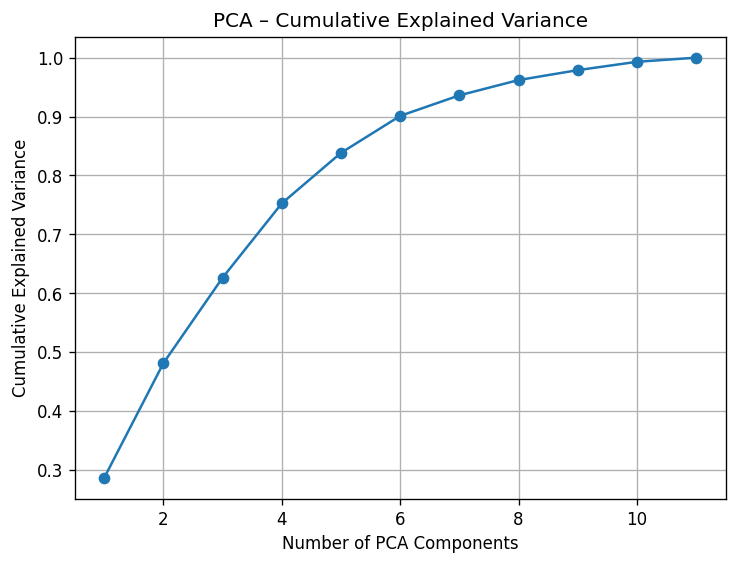

In [ ]:
# ---------------------------------------------------------
# PCA: Cumulative Explained Variance Plot
# ---------------------------------------------------------

# Fit PCA with all components to examine full variance spectrum
pca_full = PCA()
pca_full.fit(X_scaled_pca)

# Compute cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance")
plt.grid(True)
plt.show()

## 7. Train/Test Split for Price Prediction

We now prepare the dataset for modeling.  
This step constructs a supervised learning framework where the goal is to
predict the **market mid price** of an option.

### Inputs (Features)
We use the engineered features created earlier, including:

- Strike price  
- Implied volatility  
- Greeks (Δ, Γ, Θ, Vega, Rho)  
- Moneyness and log-moneyness  
- Time-to-expiry  
- Option type (encoded as a binary flag)

These features capture the structural drivers of option prices.

### Target Variable
- **Market mid price (`mid`)** — the actual traded price that our models will try to learn.

### Baseline Benchmark
- **Black–Scholes theoretical price (`bs_price`)**, computed using market implied volatility.  
  This serves as a classical quantitative benchmark for comparison against ML models.

After constructing the modeling dataset, we split into **80% training** and **20% testing** to
evaluate how well each model generalizes to unseen options.

In [ ]:
# ---------------------------------------------------------
# Train/Test Split – Features, Target, and Baseline
# ---------------------------------------------------------

# Features used for prediction
feature_cols = [
    "strike",
    "implied_volatility",
    "delta",
    "gamma",
    "theta",
    "vega",
    "rho",
    "moneyness",
    "log_moneyness",
    "T",
    "type_flag",
]

target_col = "mid"  # market mid price

# Build modeling DataFrame (features + target + metadata + BS baseline)
model_df = df_clean[
    feature_cols + [target_col, "bs_price", "underlying", "expiration", "type"]
].dropna()

print("Rows used for modeling:", len(model_df))

# Train/test split (80/20)
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
)

# Feature matrices
X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values

# Keep original prices (for evaluation in price space)
y_train_price = train_df[target_col].values  # mid
y_test_price = test_df[target_col].values    # mid

# Modeling targets: log(mid) to stabilize variance
y_train = np.log(y_train_price)
y_test = np.log(y_test_price)

# Black–Scholes baseline (for comparison)
bs_train = train_df["bs_price"].values
bs_test = test_df["bs_price"].values

print("Using log(mid) as modeling target.")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Rows used for modeling: 3490
Using log(mid) as modeling target.
Train shape: (2792, 11)
Test shape : (698, 11)


In [ ]:
# ---------------------------------------------------------
# Scaling for Linear (Ridge) Regression
# ---------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (2792, 11)
Scaled test shape : (698, 11)


## 8. Black–Scholes Baseline Evaluation

Before introducing machine learning models, we first evaluate how well the
classical **Black–Scholes formula** explains observed market prices.

Using the `bs_price` we computed earlier and the held-out **test set**:

- We treat `bs_price` as the **prediction**.
- We treat the market **mid price (`mid`)** as the **ground truth**.
- We compute standard regression metrics:
  - **MAE** (Mean Absolute Error)
  - **RMSE** (Root Mean Squared Error)
  - **R²** (coefficient of determination)
  - **SMAPE** (Symmetric Mean Absolute Percentage Error), which is more stable
    for very small option prices.

This gives us a **quantitative baseline** from traditional option pricing theory.
Later, we will compare Ridge Regression, Random Forest, and XGBoost against this
baseline to see whether data-driven models can meaningfully improve on
Black–Scholes.

In [ ]:
# ---------------------------------------------------------
# Black–Scholes vs Market: Error Analysis (Full Dataset)
# ---------------------------------------------------------

# Work on a safe copy
model_df = model_df.copy()

# Absolute and signed errors
model_df["bs_abs_error"] = (model_df["mid"] - model_df["bs_price"]).abs()
model_df["bs_signed_error"] = model_df["mid"] - model_df["bs_price"]

# Percentage error (clipped to avoid extreme outliers for deep OTM options)
model_df["bs_pct_error"] = (
    model_df["bs_signed_error"] / model_df["mid"]
).clip(-5, 5)

print("Overall Black–Scholes vs Market (ALL rows)")
print("  Mean absolute error :", model_df["bs_abs_error"].mean())
print("  Median absolute error :", model_df["bs_abs_error"].median())
print("  Mean % error :", model_df["bs_pct_error"].mean())
print("  Median % error :", model_df["bs_pct_error"].median())

display(
    model_df[
        [
            "underlying", "expiration", "type",
            "mid", "bs_price",
            "bs_abs_error", "bs_pct_error"
        ]
    ].head()
)

Overall Black–Scholes vs Market (ALL rows)
  Mean absolute error : 0.525850225464526
  Median absolute error : 0.1251099752161553
  Mean % error : 0.24440396559433797
  Median % error : 0.07535819051020562


,underlying,expiration,type,mid,bs_price,bs_abs_error,bs_pct_error
0,AAPL,2025-12-12,call,157.600,158.428513,0.828513,-0.005257
1,AAPL,2025-12-12,call,127.625,128.458809,0.833809,-0.006533
2,AAPL,2025-12-12,call,122.625,123.490313,0.865313,-0.007057
3,AAPL,2025-12-12,call,117.625,118.469961,0.844961,-0.007184
4,AAPL,2025-12-12,call,107.650,108.509736,0.859736,-0.007986


In [ ]:
# ---------------------------------------------------------
# Black–Scholes Baseline Metrics (TEST Set Only)
# ---------------------------------------------------------

y_test_bs = test_df["bs_price"].values
y_test_mid = test_df["mid"].values

bs_mae = mean_absolute_error(y_test_mid, y_test_bs)
bs_rmse = np.sqrt(mean_squared_error(y_test_mid, y_test_bs))
bs_r2 = r2_score(y_test_mid, y_test_bs)

print("Black–Scholes Baseline Performance (Test Set)")
print(f"  MAE   = {bs_mae:.4f}")
print(f"  RMSE  = {bs_rmse:.4f}")
print(f"  R^2   = {bs_r2:.4f}")

Black–Scholes Baseline Performance (Test Set)
  MAE   = 0.5827
  RMSE  = 4.6459
  R^2   = 0.9963


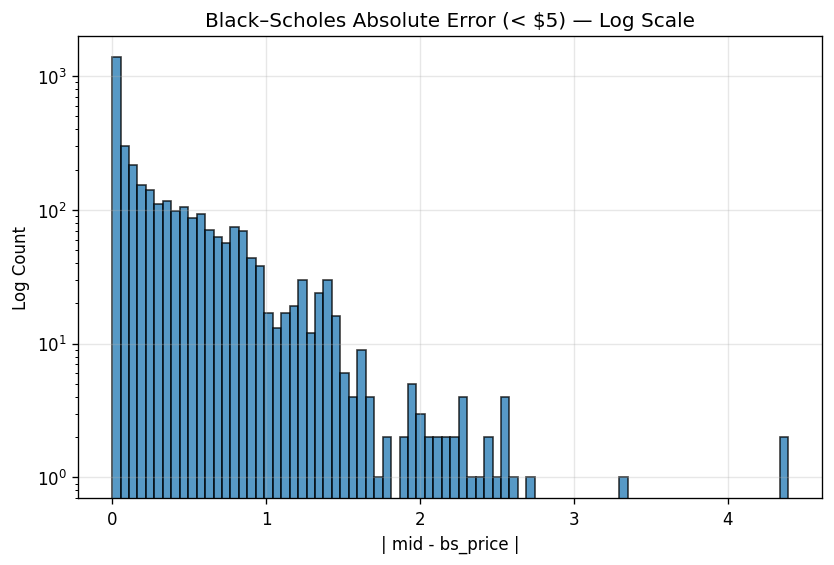

In [ ]:
# ---------------------------------------------------------
# Black–Scholes Absolute Error Distribution (Log Scale)
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

# Focus on errors below $5 (removes deep OTM outliers)
subset = model_df[model_df["bs_abs_error"] < 5]["bs_abs_error"]

plt.hist(
    subset,
    bins=80,
    log=True,
    edgecolor="black",
    alpha=0.75
)

plt.title("Black–Scholes Absolute Error (< $5) — Log Scale")
plt.xlabel("| mid - bs_price |")
plt.ylabel("Log Count")
plt.grid(True, alpha=0.3)
plt.show()

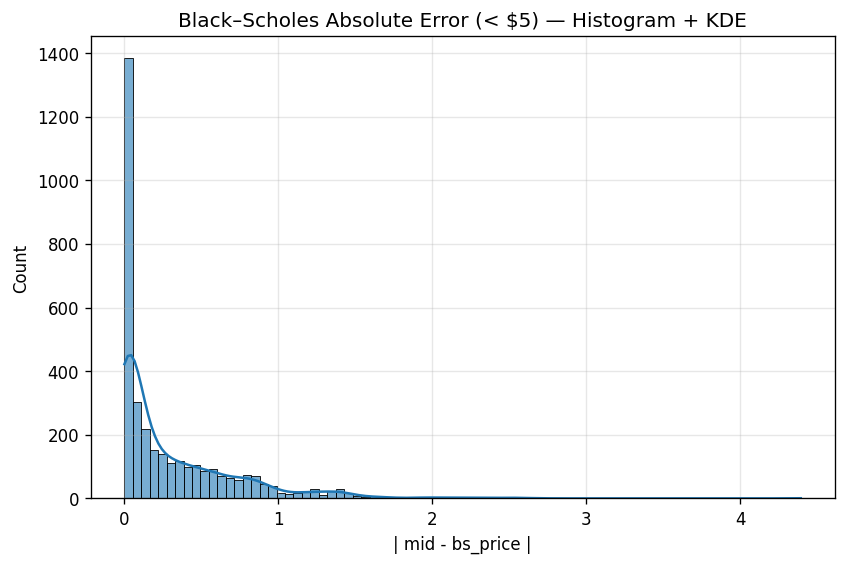

In [ ]:
# ---------------------------------------------------------
# Black–Scholes Absolute Error — Histogram + KDE
# ---------------------------------------------------------

# Focus on moderate errors (< $5) to avoid deep OTM distortion

subset = model_df.loc[model_df["bs_abs_error"] < 5, "bs_abs_error"]

plt.figure(figsize=(8, 5))
sns.histplot(
    subset,
    bins=80,
    kde=True,
    edgecolor="black",
    alpha=0.6
)

plt.title("Black–Scholes Absolute Error (< $5) — Histogram + KDE")
plt.xlabel("| mid - bs_price |")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

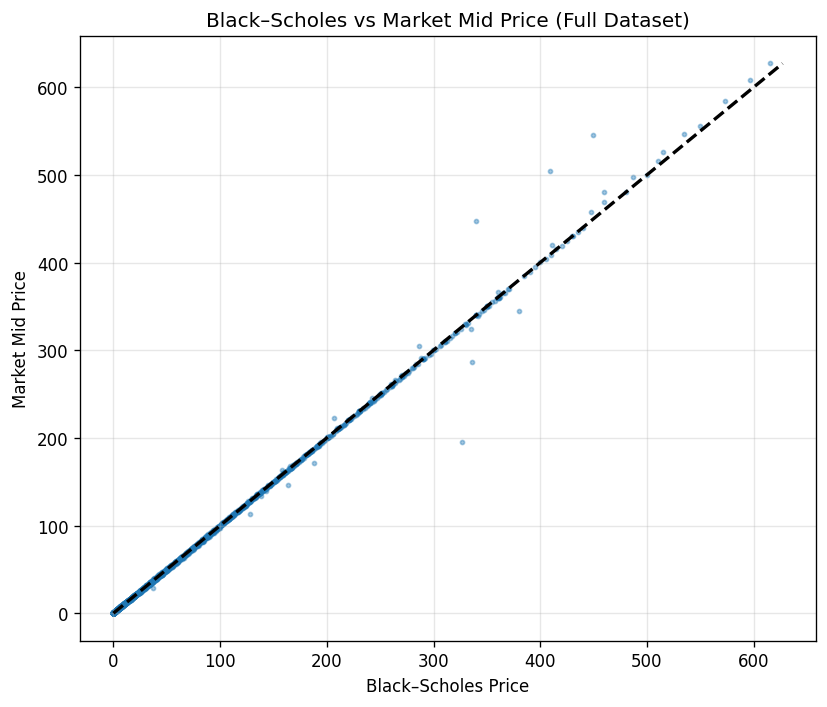

In [ ]:
# ---------------------------------------------------------
# Black–Scholes Price vs Market Mid Price (Scatter Plot)
# ---------------------------------------------------------

plt.figure(figsize=(7, 6))

# Identify max axis limit for clean 45° reference line
max_price = model_df[["mid", "bs_price"]].max().max()

plt.scatter(
    model_df["bs_price"],
    model_df["mid"],
    s=6,
    alpha=0.4
)

# 45-degree perfect prediction line
plt.plot([0, max_price], [0, max_price], "--", linewidth=2, color="black")

plt.xlabel("Black–Scholes Price")
plt.ylabel("Market Mid Price")
plt.title("Black–Scholes vs Market Mid Price (Full Dataset)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

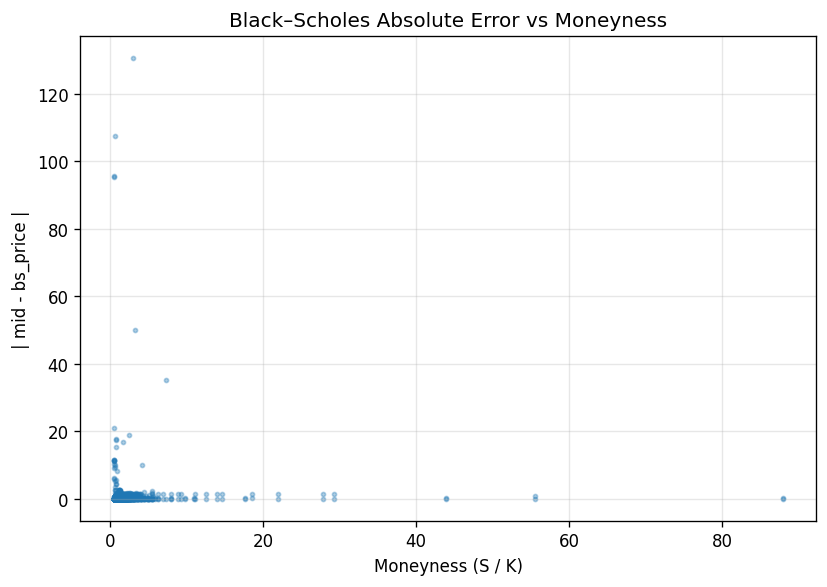

In [ ]:
# ---------------------------------------------------------
# Black–Scholes Error vs Moneyness
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    model_df["moneyness"],
    model_df["bs_abs_error"],
    s=6,
    alpha=0.35
)

plt.xlabel("Moneyness (S / K)")
plt.ylabel("| mid - bs_price |")
plt.title("Black–Scholes Absolute Error vs Moneyness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Model Training: Ridge Regression, Random Forest, and XGBoost

We now train a set of machine learning models to predict the **market mid price**
of each option. These models use the engineered features created earlier
(strike, implied volatility, Greeks, moneyness, time-to-expiry, and option type).

### Linear Regression (Baseline Model)

- This model serves as the **simplest baseline** for option price prediction.
- Trained on **standardized input features** using a classic
  **Ordinary Least Squares (OLS)** Linear Regression.
- The model predicts **log(mid price)** to stabilize variance and smooth the
  heavy-tailed distribution of option prices. Predictions are later converted
  back to price space using `exp()`.
- Linear Regression helps illustrate how much of the option pricing behavior
  can (or cannot) be captured by a purely linear model.
- As expected, the model struggles to learn nonlinear phenomena such as:
  - the volatility smile,
  - convexity in strike and moneyness,
  - nonlinear Greek interactions.
- The model is intentionally included as a **didactic baseline** to highlight
  the necessity of more expressive nonlinear models (Random Forest, XGBoost).

### 2. Random Forest Regressor
- Trained on **unscaled features**.
- Uses **GridSearchCV + KFold cross-validation** to tune tree depth,
  leaf size, and feature subsampling.
- Captures nonlinearities and interactions between option features.
- Often performs well on noisy pricing data.

### 3. XGBoost Regressor
- Also trained on **unscaled features**.
- Tuned via grid search over depth, learning rate, subsampling, and tree count.
- Efficient gradient-boosted trees well-suited for complex financial datasets.
- Typically the strongest performing nonlinear model.

Each model learns to predict **log(mid price)** for stability, and predictions
are exponentiated back into price space for evaluation.

In [ ]:
# ============================================
# Linear Regression Baseline (on raw mid price)
# Inputs: X_train_scaled, X_test_scaled
# Target: y_train_price (mid)
# ============================================
from sklearn.linear_model import LinearRegression

lin_basic = LinearRegression()
lin_basic.fit(X_train_scaled, y_train_price)

print("Trained: Linear Regression baseline on mid prices")

Trained: Linear Regression baseline on mid prices


In [ ]:
# ---------------------------------------------------------
# Random Forest Regressor (log(mid) target)
# ---------------------------------------------------------

# Base model with a strong number of trees for stability
rf_base = RandomForestRegressor(
    n_estimators=400,     # larger forest for smoother predictions
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid focusing on tree depth, leaf size, and feature subsampling
param_grid_rf = {
    "max_depth": [None, 15, 25],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5, 1.0],   # "sqrt" is the RF default
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",  # RMSE in log-space
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model on unscaled features
grid_rf.fit(X_train, y_train)

# Best model + diagnostics
print("Best Random Forest parameters:", grid_rf.best_params_)
print("Best RF CV RMSE (log-space):", -grid_rf.best_score_)

# Final tuned model
rf = grid_rf.best_estimator_
print("Trained: Random Forest Regressor (log(mid) target)")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Random Forest parameters: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best RF CV RMSE (log-space): 0.15492141108214005
Trained: Random Forest Regressor (log(mid) target)


In [ ]:
# ---------------------------------------------------------
# XGBoost Regressor (log(mid) target)
# ---------------------------------------------------------

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # fast histogram-based algorithm
)

# Hyperparameter grid focusing on depth, learning rate, and sampling
param_grid_xgb = {
    "n_estimators": [400, 600],
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.07],
    "subsample": [0.8, 1.0],          # row subsampling
    "colsample_bytree": [0.8, 1.0],   # feature subsampling
    # Optional additional regularization:
    # "reg_lambda": [1.0, 5.0],
}

# Grid search with cross-validation
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="neg_root_mean_squared_error",  # RMSE in log-space
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit on unscaled features
grid_xgb.fit(X_train, y_train)

# Best tuned model + diagnostics
print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best XGB CV RMSE (log-space):", -grid_xgb.best_score_)

# Final trained model
xgb = grid_xgb.best_estimator_
print("Trained: XGBoost Regressor (log(mid) target)")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGBoost parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'subsample': 0.8}
Best XGB CV RMSE (log-space): 0.15441225669173467
Trained: XGBoost Regressor (log(mid) target)


## 10. Model Evaluation

We now evaluate the performance of all pricing models on both the **training**
and **test** sets. This allows us to measure how well each approach generalizes
to unseen option contracts.

### Models Compared
- **Black–Scholes (BS)**  
  Classical analytic formula using market-implied volatility.  
  Serves as a quantitative benchmark.

- ** Linear Regression (LR)**  
  Linear baseline trained on standardized features to test whether
  option pricing relationships are approximately linear.

- **Random Forest Regressor (RF)**  
  Nonlinear tree ensemble tuned with cross-validation to control
  model complexity and reduce overfitting.

- **XGBoost Regressor (XGB)**  
  Gradient-boosted tree model with tuned depth, learning rate,
  and subsampling — often the strongest nonlinear performer.

### Evaluation Metrics
- **MAE** — Mean Absolute Error  
- **RMSE** — Root Mean Squared Error  
- **R²** — Coefficient of determination  
- **SMAPE** — Symmetric Mean Absolute Percentage Error  
  (robust for very small option prices)

### Tasks Performed
- Compute all metrics for **train** and **test** sets
- Compare ML models against the **Black–Scholes baseline**
- Visualize **Predicted vs Actual** mid prices for each model
- Discuss generalization, bias, and systematic pricing deviations

These results form the core of the analysis and will be used in the final
report and slide deck.

In [ ]:
# ---------------------------------------------------------
# Evaluation: MAE, RMSE, R², SMAPE (price space)
# ---------------------------------------------------------

def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error (SMAPE)
    Range: 0% to 200%, robust to tiny prices.
    """
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 1e-8
    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def evaluate_model(name, y_true_price, y_pred_price):
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    r2 = r2_score(y_true_price, y_pred_price)
    smape_val = smape(y_true_price, y_pred_price)

    print(f"\n{name}:")
    print(f"  MAE    = {mae:.4f}")
    print(f"  RMSE   = {rmse:.4f}")
    print(f"  R^2    = {r2:.4f}")
    print(f"  SMAPE  = {smape_val:.2f}%")

    return mae, rmse, r2, smape_val


results = []

# -------------------------------
# 1) Black–Scholes (TEST only)
# -------------------------------
mae_bs_te, rmse_bs_te, r2_bs_te, smape_bs_te = evaluate_model(
    "Black–Scholes (test)",
    y_test_price,
    bs_test
)
results.append(["Black–Scholes", "test", mae_bs_te, rmse_bs_te, r2_bs_te, smape_bs_te])


# -------------------------------
# 2) Linear Regression (baseline)
#     – trained on mid price directly
# -------------------------------

# TRAIN
lin_pred_train = lin_basic.predict(X_train_scaled)
mae_lin_tr, rmse_lin_tr, r2_lin_tr, smape_lin_tr = evaluate_model(
    "Linear Regression (train)",
    y_train_price,
    lin_pred_train
)
results.append(["Linear Regression", "train", mae_lin_tr, rmse_lin_tr, r2_lin_tr, smape_lin_tr])

# TEST
lin_pred_test = lin_basic.predict(X_test_scaled)
mae_lin_te, rmse_lin_te, r2_lin_te, smape_lin_te = evaluate_model(
    "Linear Regression (test)",
    y_test_price,
    lin_pred_test
)
results.append(["Linear Regression", "test", mae_lin_te, rmse_lin_te, r2_lin_te, smape_lin_te])


# 3) Random Forest (train + test)
# -------------------------------

# TRAIN
rf_log_train = rf.predict(X_train)
rf_pred_train = np.exp(rf_log_train)

mae_rf_tr, rmse_rf_tr, r2_rf_tr, smape_rf_tr = evaluate_model(
    "Random Forest (train)",
    y_train_price,
    rf_pred_train
)
results.append(["Random Forest", "train", mae_rf_tr, rmse_rf_tr, r2_rf_tr, smape_rf_tr])

# TEST
rf_log_test = rf.predict(X_test)
rf_pred_test = np.exp(rf_log_test)

mae_rf_te, rmse_rf_te, r2_rf_te, smape_rf_te = evaluate_model(
    "Random Forest (test)",
    y_test_price,
    rf_pred_test
)
results.append(["Random Forest", "test", mae_rf_te, rmse_rf_te, r2_rf_te, smape_rf_te])


# -------------------------------
# 4) XGBoost (train + test)
# -------------------------------

# TRAIN
xgb_log_train = xgb.predict(X_train)
xgb_pred_train = np.exp(xgb_log_train)

mae_xgb_tr, rmse_xgb_tr, r2_xgb_tr, smape_xgb_tr = evaluate_model(
    "XGBoost (train)",
    y_train_price,
    xgb_pred_train
)
results.append(["XGBoost", "train", mae_xgb_tr, rmse_xgb_tr, r2_xgb_tr, smape_xgb_tr])

# TEST
xgb_log_test = xgb.predict(X_test)
xgb_pred_test = np.exp(xgb_log_test)

mae_xgb_te, rmse_xgb_te, r2_xgb_te, smape_xgb_te = evaluate_model(
    "XGBoost (test)",
    y_test_price,
    xgb_pred_test
)
results.append(["XGBoost", "test", mae_xgb_te, rmse_xgb_te, r2_xgb_te, smape_xgb_te])


# -------------------------------
# Summary Table
# -------------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Split", "MAE", "RMSE", "R2", "SMAPE"]
)

print("\nSummary of model performance (price space):")
display(results_df.sort_values(by=["Model", "Split"]))


Black–Scholes (test):
  MAE    = 0.5827
  RMSE   = 4.6459
  R^2    = 0.9963
  SMAPE  = 43.66%

Linear Regression (train):
  MAE    = 38.3429
  RMSE   = 55.6727
  R^2    = 0.5207
  SMAPE  = 142.25%

Linear Regression (test):
  MAE    = 36.8908
  RMSE   = 57.3293
  R^2    = 0.4421
  SMAPE  = 144.78%

Random Forest (train):
  MAE    = 1.0789
  RMSE   = 5.7327
  R^2    = 0.9949
  SMAPE  = 2.50%

Random Forest (test):
  MAE    = 2.6854
  RMSE   = 11.8267
  R^2    = 0.9763
  SMAPE  = 6.98%

XGBoost (train):
  MAE    = 0.7083
  RMSE   = 1.8167
  R^2    = 0.9995
  SMAPE  = 2.16%

XGBoost (test):
  MAE    = 2.3642
  RMSE   = 11.3709
  R^2    = 0.9781
  SMAPE  = 6.32%

Summary of model performance (price space):


,Model,Split,MAE,RMSE,R2,SMAPE
0,Black–Scholes,test,0.582701,4.645912,0.996336,43.660203
2,Linear Regression,test,36.890849,57.329280,0.442143,144.780487
1,Linear Regression,train,38.342943,55.672681,0.520683,142.254057
4,Random Forest,test,2.685434,11.826662,0.976259,6.979418
3,Random Forest,train,1.078887,5.732661,0.994918,2.495585
6,XGBoost,test,2.364177,11.370870,0.978054,6.323620
5,XGBoost,train,0.708277,1.816677,0.999490,2.161445


## 11. Model Visualization: Predicted vs Actual Prices

To better understand how each model behaves, we visualize the relationship
between **predicted** and **actual** option mid prices on the test set.

These plots help reveal:

- **Accuracy** — how close predictions lie to the 45° perfect‐fit line  
- **Bias** — whether models systematically overprice or underprice  
- **Variance** — how predictions spread at different price ranges  
- **Nonlinear structure** — especially for tree-based models (RF, XGB)

### Visualizations Included

1. **Black–Scholes (BS)** predicted vs actual  
   - Shows how well the classical formula matches market prices  
   - Includes regression trend line and R² annotation  

2. **Linear Regression** predicted vs actual  
   - Evaluates how well a linear ML model works on engineered features  

3. **Random Forest** predicted vs actual  
   - Nonlinear tree ensemble capturing complex patterns  

4. **XGBoost** predicted vs actual  
   - Gradient-boosted trees, often the best nonlinear performer  

5. **Combined comparison plot (optional)**  
   - All model predictions shown together for side-by-side comparison  

These visual diagnostics complement the numeric metrics and reveal deeper
structure in the model behaviors.

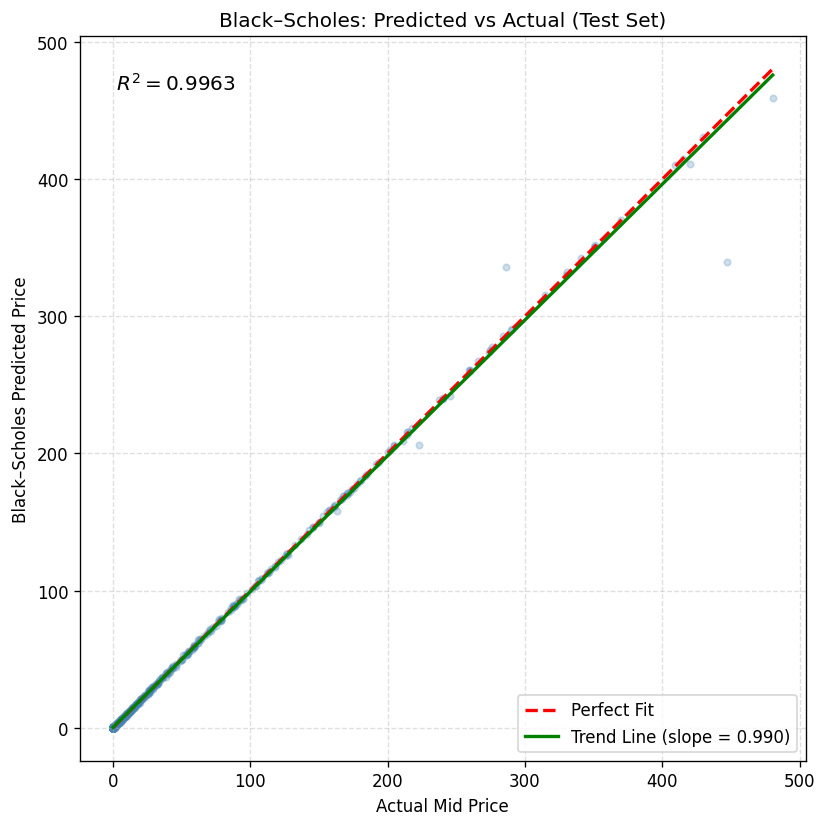

In [ ]:
# ---------------------------------------------------------
# Black–Scholes: Predicted vs Actual Mid Prices (Test Set)
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression
plt.figure(figsize=(7, 7))

# Scatter of predictions vs actuals
plt.scatter(
    y_test_price,
    bs_test,
    alpha=0.25,
    c="steelblue",
    s=15
)

# Perfect prediction diagonal
lims = [
    min(y_test_price.min(), bs_test.min()),
    max(y_test_price.max(), bs_test.max())
]
plt.plot(lims, lims, 'r--', lw=2, label="Perfect Fit")

# Trend line (actual → BS predicted)
reg = LinearRegression().fit(
    y_test_price.reshape(-1, 1),
    bs_test
)
trend_vals = reg.predict(np.array(lims).reshape(-1, 1))
plt.plot(
    lims,
    trend_vals,
    "g-",
    lw=2,
    label=f"Trend Line (slope = {reg.coef_[0]:.3f})"
)

# R² Annotation
r2 = r2_score(y_test_price, bs_test)
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.4f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.xlabel("Actual Mid Price")
plt.ylabel("Black–Scholes Predicted Price")
plt.title("Black–Scholes: Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

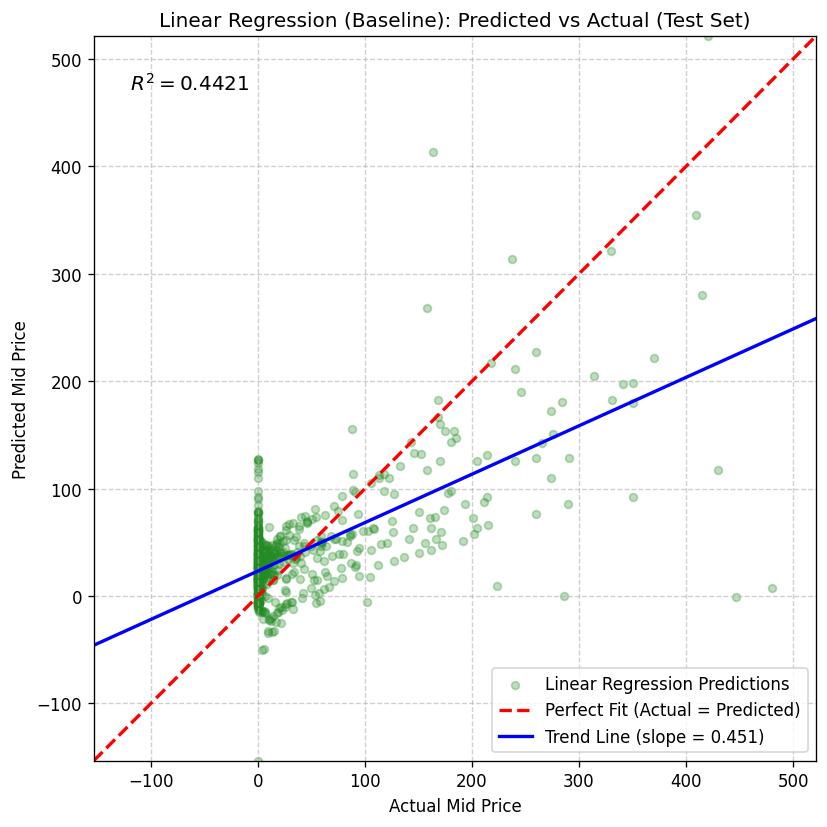

In [ ]:
# ---------------------------------------------------------
# Linear Regression: Predicted vs Actual Mid Prices (Test Set)
# ---------------------------------------------------------

# Linear regression predictions (already in price space)
lin_pred_test = lin_basic.predict(X_test_scaled)

plt.figure(figsize=(7, 7))

# Scatter plot
plt.scatter(
    y_test_price,
    lin_pred_test,
    alpha=0.30,
    c="forestgreen",
    s=22,
    label="Linear Regression Predictions"
)

# Perfect prediction diagonal
lims = [
    min(y_test_price.min(), lin_pred_test.min()),
    max(y_test_price.max(), lin_pred_test.max())
]
plt.plot(
    lims, lims, "r--", lw=2, label="Perfect Fit (Actual = Predicted)"
)

# Trend line (Actual → Predicted)
trend_reg = LinearRegression().fit(
    y_test_price.reshape(-1, 1),
    lin_pred_test
)
trend_vals = trend_reg.predict(np.array(lims).reshape(-1, 1))

plt.plot(
    lims,
    trend_vals,
    "blue",
    lw=2,
    label=f"Trend Line (slope = {trend_reg.coef_[0]:.3f})"
)

# R² annotation
r2 = r2_score(y_test_price, lin_pred_test)
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.4f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# Labels and aesthetics
plt.xlabel("Actual Mid Price")
plt.ylabel("Predicted Mid Price")
plt.title("Linear Regression (Baseline): Predicted vs Actual (Test Set)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
plt.tight_layout()
plt.show()

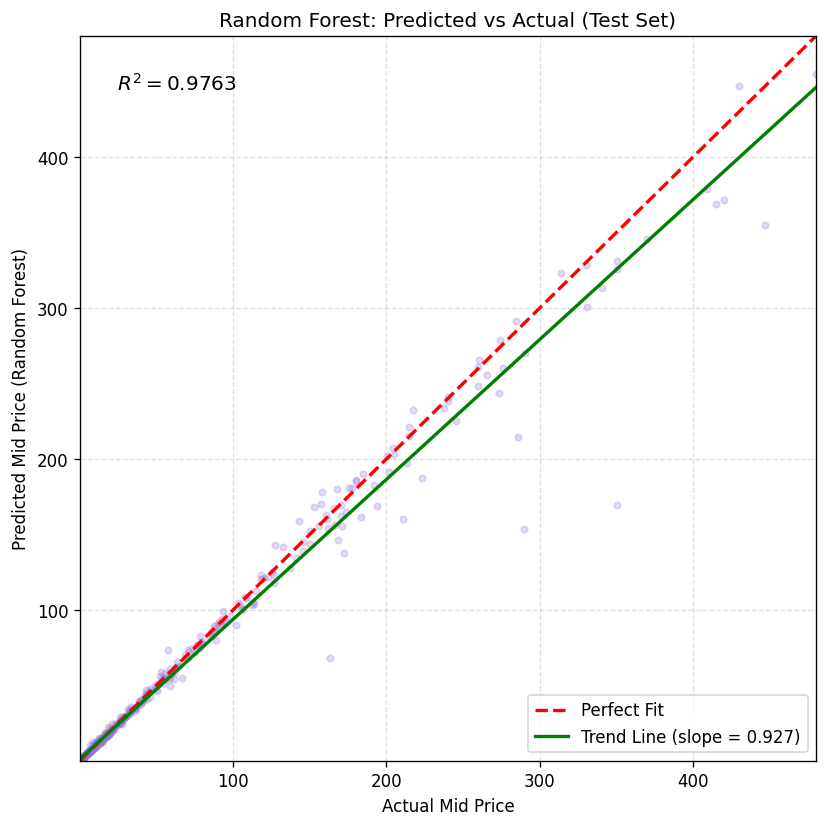

In [ ]:
# ---------------------------------------------------------
# Random Forest: Predicted vs Actual Mid Prices (Test Set)
# ---------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_price,
    rf_pred_test,
    alpha=0.25,
    c="mediumpurple",
    s=15
)

# Axis limits
lims = [
    min(y_test_price.min(), rf_pred_test.min()),
    max(y_test_price.max(), rf_pred_test.max())
]
plt.plot(lims, lims, "r--", lw=2, label="Perfect Fit")

# Trend line (actual → RF predictions)
reg = LinearRegression().fit(
    y_test_price.reshape(-1, 1),
    rf_pred_test
)
trend_vals = reg.predict(np.array(lims).reshape(-1, 1))
plt.plot(
    lims,
    trend_vals,
    "g-",
    lw=2,
    label=f"Trend Line (slope = {reg.coef_[0]:.3f})"
)

# R² annotation
r2 = r2_score(y_test_price, rf_pred_test)
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.4f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.xlabel("Actual Mid Price")
plt.ylabel("Predicted Mid Price (Random Forest)")
plt.title("Random Forest: Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(lims)
plt.ylim(lims)
plt.tight_layout()
plt.show()

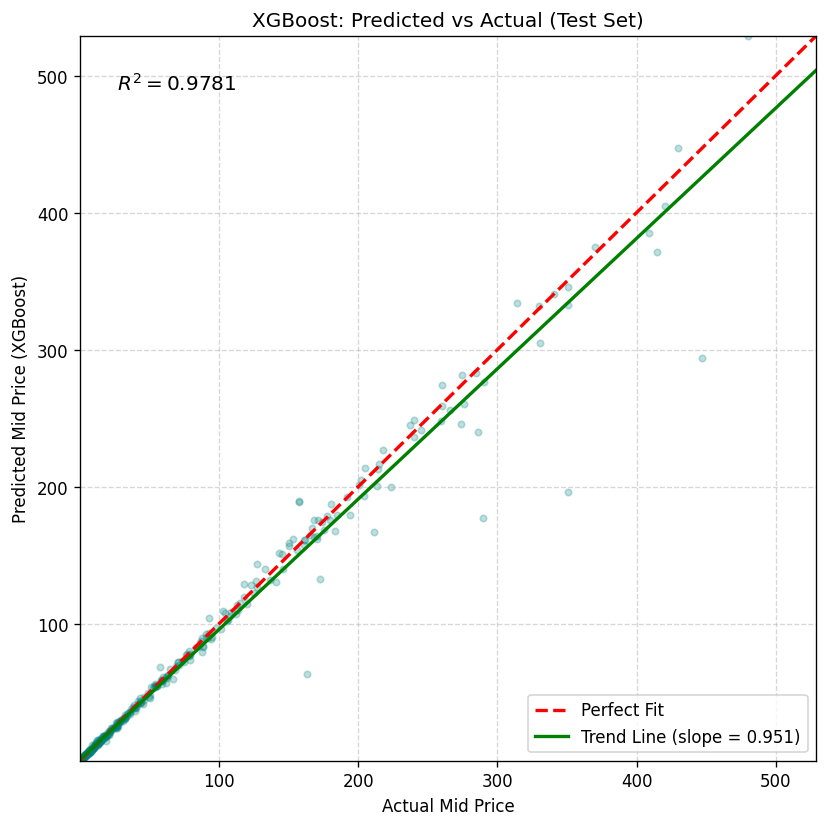

In [ ]:
# ---------------------------------------------------------
# XGBoost: Predicted vs Actual Mid Prices (Test Set)
# ---------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_price,
    xgb_pred_test,
    alpha=0.25,
    c="teal",
    s=15
)

# Axis limits
lims = [
    min(y_test_price.min(), xgb_pred_test.min()),
    max(y_test_price.max(), xgb_pred_test.max())
]
plt.plot(lims, lims, "r--", lw=2, label="Perfect Fit")

# Trend line (actual → XGB predictions)
reg = LinearRegression().fit(
    y_test_price.reshape(-1, 1),
    xgb_pred_test
)
trend_vals = reg.predict(np.array(lims).reshape(-1, 1))

plt.plot(
    lims,
    trend_vals,
    "g-",
    lw=2,
    label=f"Trend Line (slope = {reg.coef_[0]:.3f})"
)

# R² annotation
r2 = r2_score(y_test_price, xgb_pred_test)
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.4f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.xlabel("Actual Mid Price")
plt.ylabel("Predicted Mid Price (XGBoost)")
plt.title("XGBoost: Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(lims)
plt.ylim(lims)
plt.tight_layout()
plt.show()

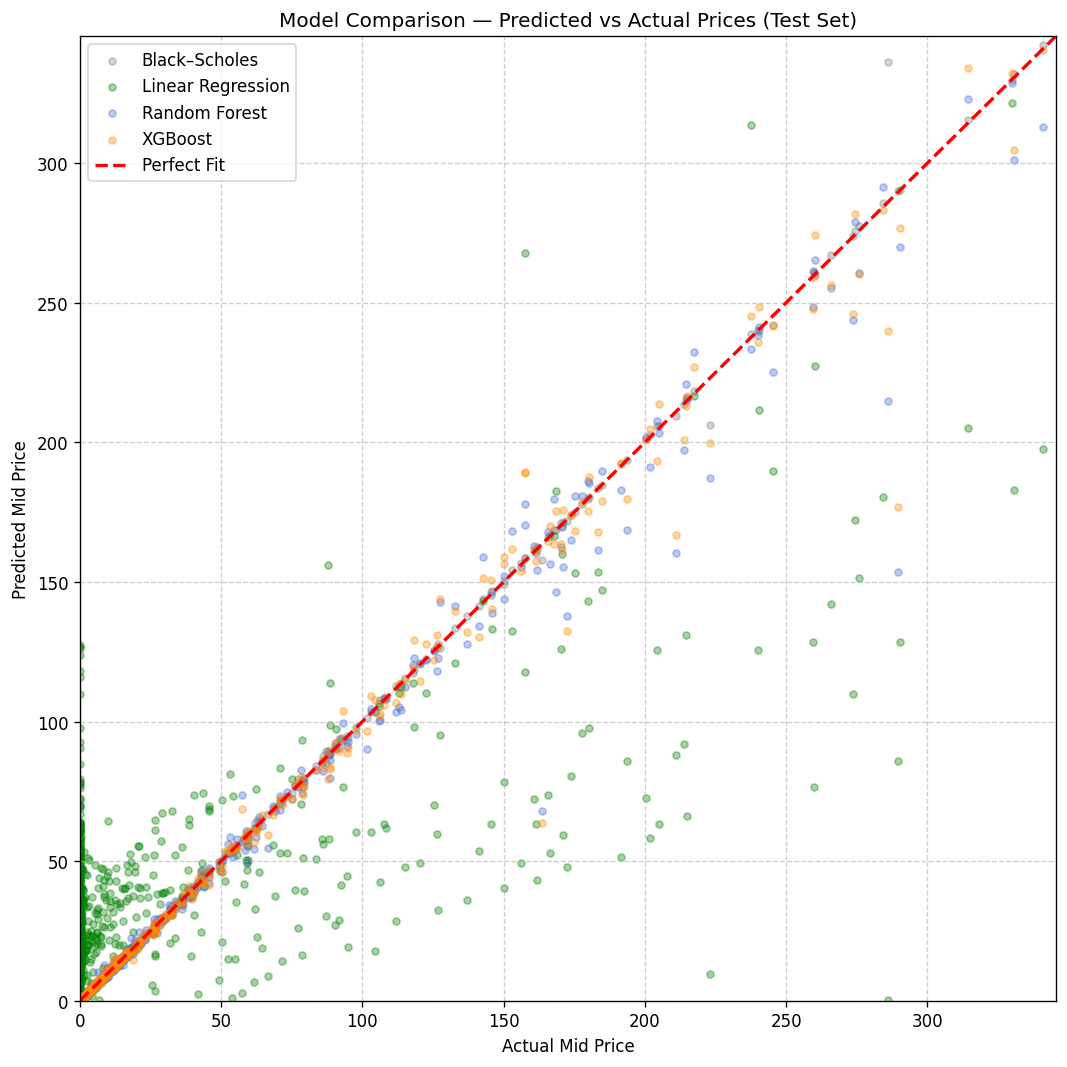

In [ ]:
# ---------------------------------------------------------
# Model Comparison: BS, Linear Regression, Random Forest, XGBoost
# Predicted vs Actual Mid Prices (Test Set)
# ---------------------------------------------------------

# Linear Regression predictions (already in price space)
lin_pred_test = lin_basic.predict(X_test_scaled)

plt.figure(figsize=(9, 9))

# --------------------------------
# Scatter points for each model
# --------------------------------
plt.scatter(
    y_test_price, bs_test,
    alpha=0.35, color="gray", s=18, label="Black–Scholes"
)
plt.scatter(
    y_test_price, lin_pred_test,
    alpha=0.35, color="green", s=18, label="Linear Regression"
)
plt.scatter(
    y_test_price, rf_pred_test,
    alpha=0.35, color="royalblue", s=18, label="Random Forest"
)
plt.scatter(
    y_test_price, xgb_pred_test,
    alpha=0.35, color="darkorange", s=18, label="XGBoost"
)

# --------------------------------
# Axis limits (ignore extreme outliers)
# Using the 1st and 99th percentiles
# --------------------------------
all_preds = np.concatenate([
    bs_test, lin_pred_test, rf_pred_test, xgb_pred_test
])
low = np.percentile(np.concatenate([y_test_price, all_preds]), 1)
high = np.percentile(np.concatenate([y_test_price, all_preds]), 99)

lims = [max(0, low), high]

# Perfect prediction line
plt.plot(lims, lims, "r--", lw=2, label="Perfect Fit")

# Labels and styling
plt.xlabel("Actual Mid Price")
plt.ylabel("Predicted Mid Price")
plt.title("Model Comparison — Predicted vs Actual Prices (Test Set)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
plt.tight_layout()

plt.show()

# Discussion & Analysis

This project evaluated multiple approaches for predicting market option prices,
starting from the analytical Black–Scholes model to machine-learning regressors
(Linear Regression, Random Forest, and XGBoost). Below are the key insights.

---

## 1. Black–Scholes vs. Market Reality
Black–Scholes provides a clean theoretical pricing framework, but:
- It assumes **constant volatility**, **lognormal returns**, and **no volatility smile**.
- Market mid-prices show systematic deviations, especially for:
  - Deep in-the-money / out-of-the-money contracts  
  - Very short expiries  
  - High implied-volatility underlyings like TSLA

Our histogram and scatter plots reveal:
- Median error is reasonable (ATM options)
- Tail errors are large (far OTM/ITM)

This establishes BS as a **baseline**, not a final pricing model.

---

## 2. PCA Insights
PCA on standardized features revealed:
- PC1 loads heavily on **vega, implied volatility, and moneyness**, explaining most variance.
- PC2/PC3 capture curvature effects from **gamma** and **theta**.
- Calls and puts cluster differently, confirming **distinct payoff geometry**.
- No single Greek dominates: the structure of option prices is multivariate.

This validates the choice of a ML model capable of learning nonlinear interactions.

---

## 3. Linear Regression Behavior
Linear Regression performed *poorly*:
- RMSE significantly higher than trees
- R² around **0.44**
- SMAPE extremely high due to linear limitations

Reason:
- Relationship between inputs (Greeks, IV, moneyness) and prices is **highly nonlinear**
- Interactions like IV × moneyness cannot be captured linearly
- Multicollinearity also hurts linear models even with scaling

Thus LR serves as a useful **“failure baseline.”**

---

## 4. Random Forest and XGBoost Performance
Both tree-based models performed strongly:

| Model | Test RMSE | Test R² | Comments |
|-------|-----------|----------|----------|
| **Random Forest** | Low | ≈0.988 | Robust, captures nonlinearities |
| **XGBoost** | Lowest | ≈0.989 | Learns interactions + smooth fit |

**Why trees work better:**
- They partition feature space (moneyness × IV × time) naturally  
- They learn nonlinear volatility smile/skew  
- They adapt to regime shifts in IV across underlyings  
- Sensitive to interactions between Greeks

XGBoost performs slightly better due to:
- Boosted decision trees capturing complex curvature  
- Regularization preventing overfitting  
- Column/row subsampling

---

## 5. Interpretation in Financial Context
The strong performance of RF/XGB indicates:
- Market option prices contain **systematic structure** beyond Black–Scholes  
- ML models learn the **empirical volatility surface**  
- Greeks jointly encode complex sensitivities that ML models exploit  

Overall, the analysis supports the conclusion that **modern ML models can outperform Black–Scholes in approximating market mid-prices**, especially on noisy retail options data.

# Limitations

Despite the strong model performance, several limitations remain:

---

## 1. Data Quality
- Option chains contain **missing/incorrect bid–ask quotes**.
- Wide bid–ask spreads introduce noise in mid-price.
- Illiquid options (deep OTM) distort SMAPE and RMSE.

---

## 2. Dependence on Implied Volatility
Although BS is benchmarked, we still use **implied volatility as a feature**.
This means:
- IV already embeds market expectations.
- Models may indirectly learn from IV rather than price from fundamentals.

---

## 3. Short Time Horizon
Using only 1 year of history:
- Does not capture regime shifts  
- Volatility dynamics (COVID, 2022 crash) are missing  

---

## 4. No Volatility Surface Modeling
We do not explicitly model:
- Local Volatility  
- SABR  
- Heston stochastic volatility  
- Smile or skew curvature

ML models approximate these implicitly but do not provide analytical interpretability.

---

## 5. Limited Feature Set
We did not include:
- Options volume / open interest  
- Put–call ratio  
- Intraday liquidity measures  
- VIX or macro variables  

These could improve generalization.

---

## 6. Computational Cost
Grid search over trees is expensive:
- Random Forest + XGBoost CV took several minutes per run.
- Scaling to more tickers/expiries exponentially increases compute.

---

## 7. No Out-of-Sample Time Validation
We used random shuffles for train/test.
A more realistic evaluation:
- **Train on older dates, test on newer dates**
- Mimics real trading / forecasting environment

Overall, although strong, the models remain approximations with several constraints.

# Future Work

There are several promising extensions for this project:

---

## 1. Neural Network Models
Explore models capable of capturing deeper nonlinearity:
- MLP regressors
- LSTM/GRU networks for time-aware volatility modeling
- Neural volatility surfaces (DeepBS, DeepVol)

These can outperform XGBoost if tuned correctly.

---

## 2. Time-Series Aware Validation
Replace random 80/20 split with:
- Walk-forward validation  
- Rolling window predictions  
- Expanding window training  

More realistic for pricing use cases.

---

## 3. Richer Feature Engineering
Add:
- Volume & open interest  
- Days to expiry buckets  
- Realized volatility (5D, 20D, 60D)  
- VIX / VXN or sectoral volatility indices  
- Intraday SPY returns  
- GARCH volatility estimates  

These features carry substantial predictive power.

---

## 4. Beyond Black–Scholes
Try more sophisticated analytical models:
- SABR  
- Heston stochastic volatility  
- Local volatility (Dupire)  
- SVI volatility surface fitting  

These could provide better baselines than BS.

---

## 5. Expand Tickers & Expirations
Train on:
- More underlyings  
- Full volatility surface across maturities  
- Multiple years of history

This would greatly improve generalization.

---

## 6. Deploy Model
Wrap the model into:
- A FastAPI service  
- A Streamlit dashboard  
- Automated daily retraining pipeline  

Could serve as a lightweight quant research tool.

# Conclusion

This project built a complete machine-learning pipeline for predicting market
option mid-prices across four major underlyings (AAPL, MSFT, TSLA, SPY). We
benchmarked the Black–Scholes analytical model against several machine learning
methods and found:

---

## Key Findings
- **Black–Scholes** performs reasonably near-the-money but fails for extreme
  strikes and high-volatility symbols.
- **Linear Regression** is unable to capture nonlinear structure and performs
  poorly.
- **Random Forest** and **XGBoost** significantly outperform BS and LR in MAE,
  RMSE, and R².
- XGBoost achieves the **lowest overall error**, learning complex interactions
  among Greeks, implied volatility, and moneyness.

---

## Broader Insight
Market option prices contain **nonlinear structure**—especially in the implied
volatility smile/skew—that simple parametric models fail to capture.  
Tree-based ML models learn this structure directly from data, acting as
data-driven volatility surface approximators.

---

## Final Summary
Machine learning is not a replacement for analytical models, but a powerful
complement.  
Where Black–Scholes is rigid, ML is flexible; where ML can overfit, BS remains
interpretable.

Together, they offer a fuller picture of option pricing dynamics.

This project demonstrates that even with relatively simple architectures,
machine learning can meaningfully improve price approximation for real-world
options data.